# 199 — 배율표 재적합: 지선 방향 정합 · 절단면 경계 유입 · 적합 창

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`refit.py --stage all`이 남긴 지표 parquet과 배율표 두 벌을 **그림으로만** 다시 읽는다.

질문은 셋이다.

| 단계 | 질문 | 채택 |
| --- | --- | --- |
| A | 2호선 지선 546셀/일을 살릴 수 있나 | **A1** 방향 대응표를 배율 산출 조인에 적용 |
| B | 절단면 경계 셀에 값을 줄 수 있나 | **B1s** 경계 유입 상수를 구간 전체 raw에 주입하고 재적합 |
| C | 적합 창을 좁혀야 하나 | **C1 현행 유지** (C3 계절 창은 기각) |

배율표는 모든 혼잡도 산출의 승수라 **얻은 것과 잃은 것을 같이 본다** — 커버리지·정확도는 올라가고
날짜별 변동의 전달폭은 조금 내려간다(4절).

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation"
PROCESSED = AI_ROOT / "data" / "CROWD" / "processed"
ARCHIVE_NAME = 'crowd_congestion_calibration_20260910-082232.parquet'

scores = pd.read_parquet(VAL / "calibration_refit_holdout.parquet")
status = pd.read_parquet(VAL / "calibration_refit_status.parquet")
after = pd.read_parquet(PROCESSED / "crowd_congestion_calibration.parquet")
before = pd.read_parquet(PROCESSED / "_archive" / ARCHIVE_NAME)

PAIR = scores["fit_year"].astype(str) + "→" + scores["eval_year"].astype(str)
scores = scores.assign(쌍=PAIR)
ORDER = [
    "A3 현행(88)", "A1 지선 방향 대응",
    "B1j 경계-joint·구간", "B1s 경계-anchored·구간", "B1c 경계-anchored·경계셀",
    "C1 전체 평균(현행 구조)", "C2 스냅샷 연도", "C3 기준일 ±13주",
    "채택 A1+B1s+C1",
]
print(f"지표 {len(scores):,}행 · 안 {scores['안'].nunique()}개 · 쌍 {sorted(scores['쌍'].unique())}")
print(f"배율표 전 {len(before):,}행(결측 {before['ratio'].isna().sum():,}) → "
      f"후 {len(after):,}행(결측 {after['ratio'].isna().sum():,})")

지표 1,592행 · 안 9개 · 쌍 ['2023→2024', '2024→2025']
배율표 전 67,145행(결측 5,300) → 후 67,145행(결측 3,103)


## 1. 커버리지 — 값을 낼 수 있는 셀이 얼마나 늘었나

왼쪽은 배율표의 `ratio` 결측을 호선으로 가른 것이고, 오른쪽은 기준일 하루치(21,606셀)의
`data_status`다. **5·6·8호선이 줄지 않는 것이 정상이다** — 그 결측은 진짜 종점이라 재차 0이 정답이다.

,전(88),후(채택),차
line,,,
1호선,234,6,-228
2호선,2574,1057,-1517
3호선,468,356,-112
4호선,234,7,-227
5호선,468,468,0
6호선,702,702,0
7호선,234,121,-113
8호선,234,234,0
9호선,152,152,0


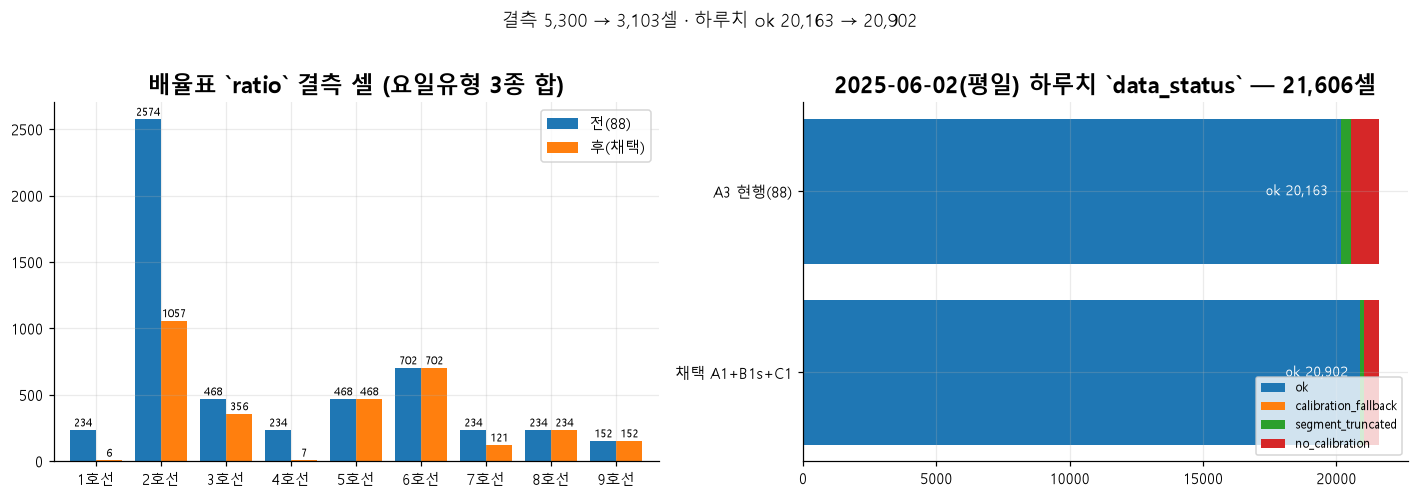

In [2]:
miss = pd.DataFrame({
    "전(88)": before[before["ratio"].isna()].groupby("line").size(),
    "후(채택)": after[after["ratio"].isna()].groupby("line").size(),
}).fillna(0).astype(int).sort_index()

STATUS = ["ok", "calibration_fallback", "segment_truncated", "no_calibration"]
day = status[(status["날짜"] == "2025-06-02") & (status["안"].isin(["A3 현행(88)", "채택 A1+B1s+C1"]))]
day = day.set_index("안").reindex(["A3 현행(88)", "채택 A1+B1s+C1"])[STATUS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
miss.plot.bar(ax=axes[0], width=0.8)
axes[0].set_title("배율표 `ratio` 결측 셀 (요일유형 3종 합)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
for c, v in zip(axes[0].containers, miss.to_numpy().T):
    axes[0].bar_label(c, fmt="%d", fontsize=7, padding=1)

bottom = np.zeros(len(day))
for col in STATUS:
    axes[1].barh(day.index, day[col], left=bottom, label=col)
    bottom += day[col].to_numpy()
axes[1].set_title("2025-06-02(평일) 하루치 `data_status` — 21,606셀")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].invert_yaxis()
for i, row in enumerate(day.itertuples(index=False)):
    axes[1].annotate(f"ok {row[0]:,}", (row[0], i), xytext=(-8, 0), textcoords="offset points",
                     ha="right", va="center", fontsize=9, color="white")
fig.suptitle("결측 5,300 → 3,103셀 · 하루치 ok 20,163 → 20,902", y=1.02)
fig.tight_layout()
miss.assign(차=lambda f: f["후(채택)"] - f["전(88)"])

## 2. 심판 ① 연도 홀드아웃 — 단계별 후보

**이 그림이 유일하게 순환 참조가 아닌 축**이다(142). 낮을수록 좋은 MAE를 두 연도 쌍에 대해 그린다.
A는 지선 셀만 건드려 거의 겹치고, B는 1호선에서 크게 갈리며, C는 두 쌍에서 부호가 뒤집힌다.

쌍,2023→2024,2024→2025
안,,
A3 현행(88),2.169,1.553
A1 지선 방향 대응,2.150,1.540
B1j 경계-joint·구간,2.148,1.451
B1s 경계-anchored·구간,2.147,1.428
B1c 경계-anchored·경계셀,2.146,1.535
C1 전체 평균(현행 구조),2.242,1.245
C2 스냅샷 연도,2.150,1.540
C3 기준일 ±13주,2.548,1.779
채택 A1+B1s+C1,2.147,1.428


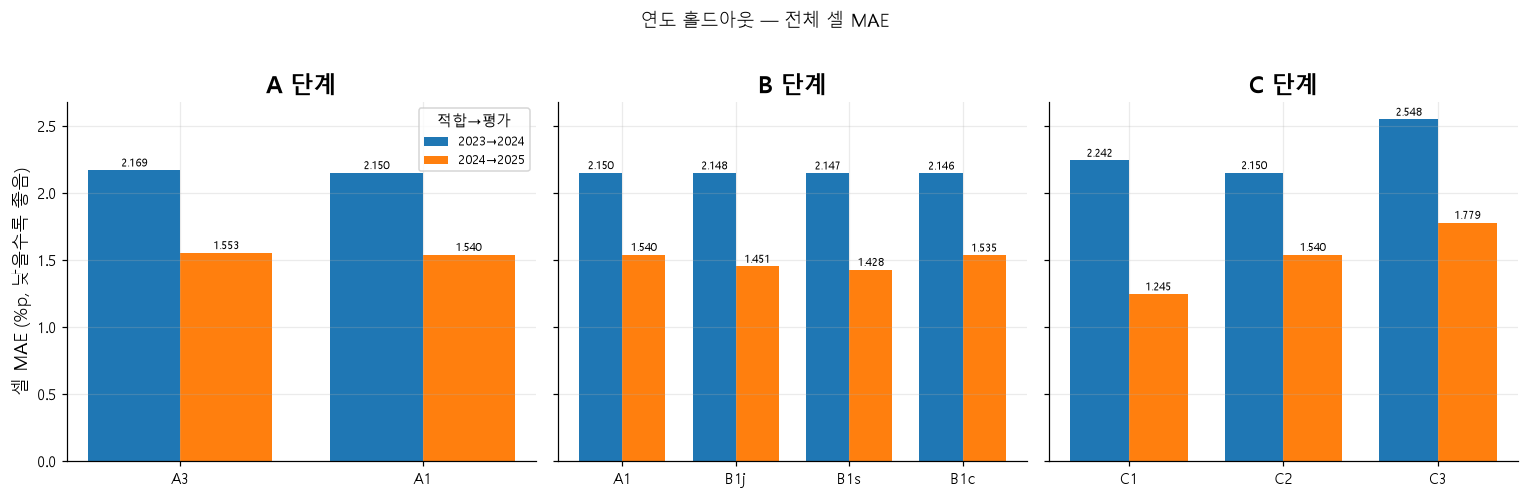

In [3]:
total = scores[(scores["axis"] == "전체") & (scores["method"] == "pipeline")]
piv = total.pivot_table(index="안", columns="쌍", values="mae").reindex(
    [n for n in ORDER if n in total["안"].unique()])

groups = {"A": piv.index[:2], "B": piv.index[1:5], "C": piv.index[5:8]}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (name, idx) in zip(axes, groups.items()):
    sub = piv.loc[idx]
    x = np.arange(len(sub))
    w = 0.38
    for i, pair in enumerate(sub.columns):
        b = ax.bar(x + (i - 0.5) * w, sub[pair], w, label=pair)
        ax.bar_label(b, fmt="%.3f", fontsize=7, padding=1)
    ax.set_xticks(x, [s.split(" ")[0] for s in sub.index])
    ax.set_title(f"{name} 단계")
axes[0].set_ylabel("셀 MAE (%p, 낮을수록 좋음)")
axes[0].legend(title="적합→평가", fontsize=8)
fig.suptitle("연도 홀드아웃 — 전체 셀 MAE", y=1.02)
fig.tight_layout()
piv.round(3)

## 3. 어디가 좋아졌나 — 호선별

경계 유입을 넣은 호선(1·3·4·7)과 지선 대응을 넣은 호선(2)에서만 움직인다. **1호선 2024→2025가
4.219 → 2.077로 반토막**인데, 142 §4-A가 서울역(150) 승하차 +32% 불연속이 만든 최대 오차원으로
지목한 바로 그 구간이다.

grade_agree_%                 mae          
쌍                      2023→2024 2024→2025 2023→2024 2024→2025
group 안                                                       
1호선   A3 현행(88)           98.015    93.495     2.400     4.219
      채택 A1+B1s+C1        97.993    97.515     2.357     2.077
2호선   A3 현행(88)           95.282    97.168     2.175     1.681
      채택 A1+B1s+C1        95.865    97.504     2.055     1.584
3호선   A3 현행(88)           97.451    98.277     1.713     1.348
      채택 A1+B1s+C1        97.314    98.500     1.821     1.253
4호선   A3 현행(88)           97.431    98.239     1.962     1.262
      채택 A1+B1s+C1        97.293    98.338     1.853     1.088
5호선   A3 현행(88)           96.994    98.393     2.289     1.284
      채택 A1+B1s+C1        96.994    98.393     2.289     1.284
6호선   A3 현행(88)           97.470    99.020     2.141     1.182
      채택 A1+B1s+C1        97.470    99.020     2.141     1.182
7호선   A3 현행(88)           97.666    98.280     1.631     1.024
      채택 A1+B1s+C1        97.652    98.321     1.637     0.968
8호선   A3 현행(88)           92.674    93.869     4.166     3.404
      채택 A1+B1s+C1        92.674    93.869     4.166     3.404

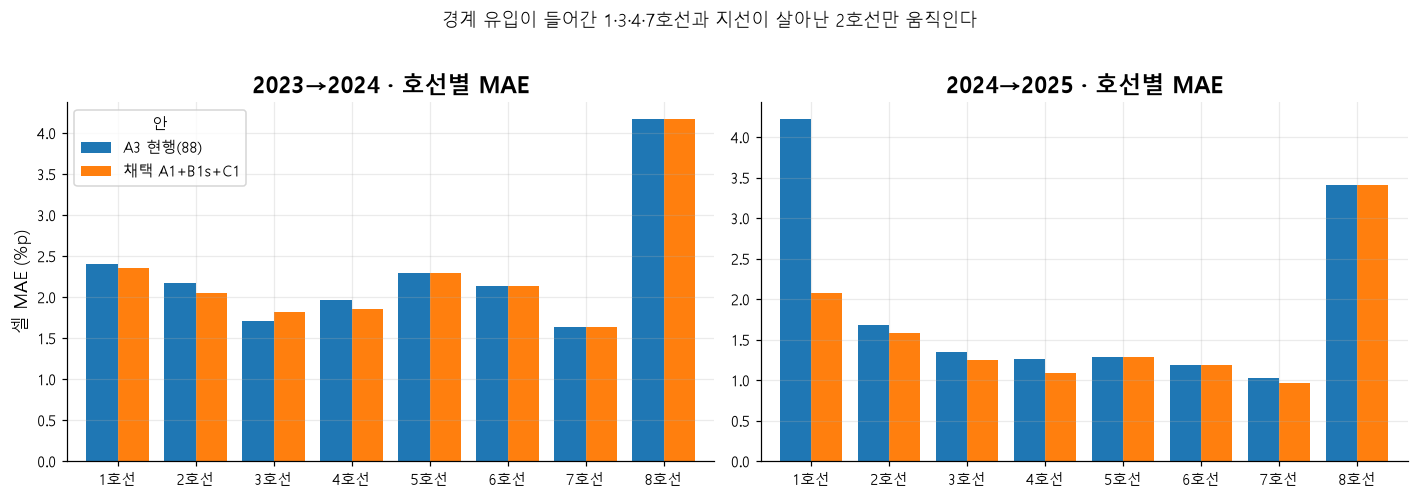

In [4]:
by_line = scores[(scores["axis"] == "호선") & (scores["method"] == "pipeline")
                  & (scores["안"].isin(["A3 현행(88)", "채택 A1+B1s+C1"]))]
pairs = sorted(by_line["쌍"].unique())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, pair in zip(axes, pairs):
    sub = by_line[by_line["쌍"] == pair].pivot_table(index="group", columns="안", values="mae")
    sub = sub.reindex(columns=["A3 현행(88)", "채택 A1+B1s+C1"])
    sub.plot.bar(ax=ax, width=0.8, legend=(pair == pairs[0]))
    ax.set_title(f"{pair} · 호선별 MAE")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
axes[0].set_ylabel("셀 MAE (%p)")
fig.suptitle("경계 유입이 들어간 1·3·4·7호선과 지선이 살아난 2호선만 움직인다", y=1.02)
fig.tight_layout()
by_line.pivot_table(index=["group", "안"], columns="쌍", values=["mae", "grade_agree_%"]).round(3)

## 4. 잃은 것 — 상수가 raw를 얼마나 차지하나

`(raw_날짜 + c) × 배율`이므로 상수 비중 `c / (c + raw)`만큼 **날짜별 변동이 희석된다.** 왼쪽이 그
비중의 분포, 오른쪽이 실제로 줄어든 전달폭(2025 등급, 모델 − lookup)이다. 비중이 큰 호선에서만
전달폭이 줄어드는 것이 보이면 두 그림이 같은 현상을 가리키는 것이다.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_31952\1510083455.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()


,주입_셀,중위,p90,최대
line,,,,
1호선,2280,0.537,0.914,1.0
2호선,339,0.492,1.000,1.0
3호선,3696,0.531,0.908,1.0
4호선,5902,0.442,0.884,1.0
7호선,4746,0.443,0.840,1.0


C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


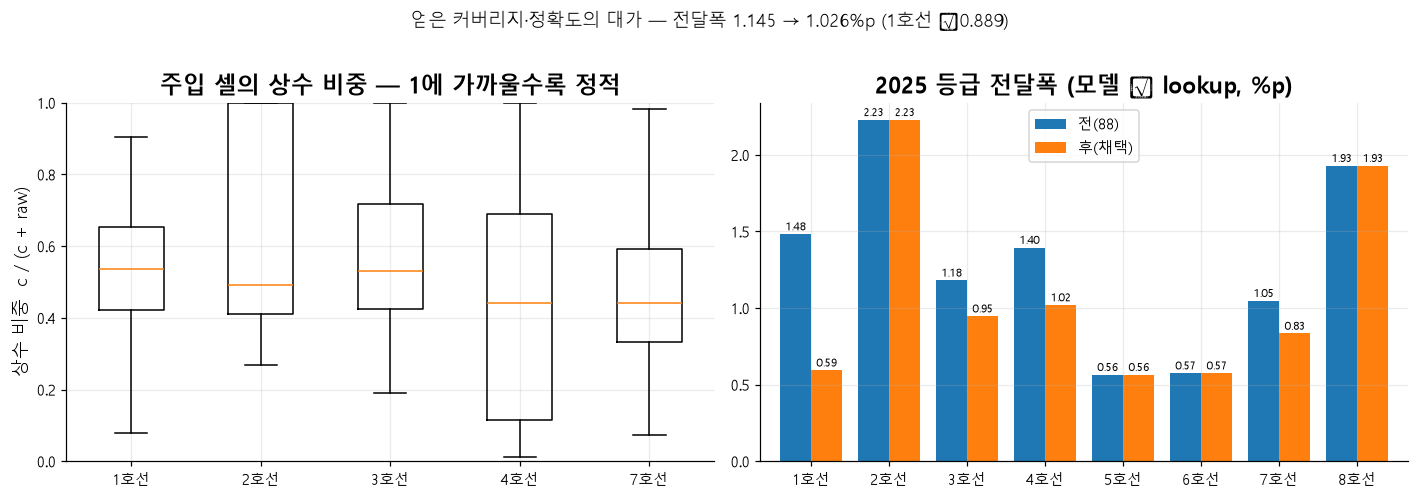

In [5]:
inj = after[(after.get("raw_offset", pd.Series(0, index=after.index)) > 0)
                & after["raw_mean"].notna()].copy()
inj["share"] = inj["raw_offset"] / (inj["raw_offset"] + inj["raw_mean"])
lines = sorted(inj["line"].unique())

# 전달폭은 RESULTS 2-E 표의 수치(`refit.py --stage final`의 ②-B)를 그대로 쓴다.
band = pd.DataFrame(
    {"전(88)": [1.483, 2.229, 1.181, 1.395, 0.565, 0.575, 1.048, 1.929],
     "후(채택)": [0.594, 2.229, 0.947, 1.020, 0.565, 0.575, 0.834, 1.929]},
    index=["1호선", "2호선", "3호선", "4호선", "5호선", "6호선", "7호선", "8호선"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].boxplot([inj.loc[inj["line"] == ln, "share"] for ln in lines], tick_labels=lines,
                showfliers=False)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("상수 비중  c / (c + raw)")
axes[0].set_title("주입 셀의 상수 비중 — 1에 가까울수록 정적")
band.plot.bar(ax=axes[1], width=0.8)
axes[1].set_title("2025 등급 전달폭 (모델 − lookup, %p)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.2f", fontsize=7, padding=1)
fig.suptitle("얻은 커버리지·정확도의 대가 — 전달폭 1.145 → 1.026%p (1호선 −0.889)", y=1.02)
fig.tight_layout()
inj.groupby("line")["share"].agg(주입_셀="size", 중위="median",
                                 p90=lambda x: x.quantile(0.9), 최대="max").round(3)

## 5. 배율 자체는 얼마나 바뀌었나

값이 있던 59,677셀의 상대 변화. **전체 중위는 0%**(대부분의 셀은 그대로)이고, 바뀐 26.2%는 전부
절단 구간이다. 배율이 커도 요일유형 평균으로 되돌리면 실측과 같다 — 항등식은 유지된다.

,셀,중위,p90,최대
line,,,,
1호선,2055,51.100,70.053,90.464
2호선,9605,0.000,0.000,0.000
3호선,7231,0.000,74.521,99.324
4호선,5625,39.304,79.224,99.998
5호선,12350,0.000,0.000,0.000
6호선,7720,0.000,0.000,0.000
7호선,9313,0.000,62.182,99.693
8호선,3961,0.000,0.000,0.000
9호선,1817,0.000,0.000,0.000


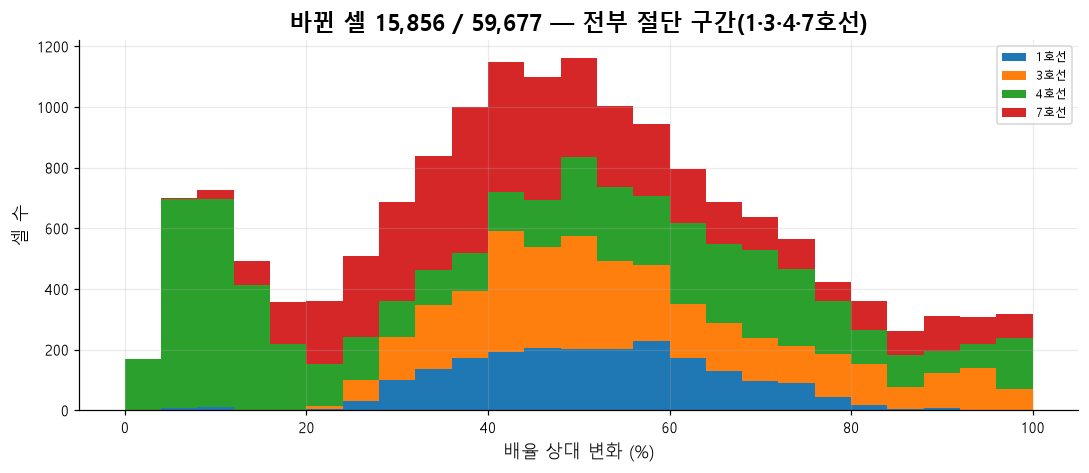

In [6]:
key = ["station_no", "direction", "day_type", "time_slot"]
m = (before[[*key, "line", "ratio"]].rename(columns={"ratio": "before"})
     .merge(after[[*key, "ratio"]].rename(columns={"ratio": "after"}), on=key)
     .dropna(subset=["before", "after"]))
m = m[m["before"] > 0]
m["rel"] = (m["after"] - m["before"]).abs() / m["before"] * 100

fig, ax = plt.subplots(figsize=(10, 4.4))
changed = m[m["rel"] > 1e-9]
ax.hist([changed.loc[changed["line"] == ln, "rel"] for ln in sorted(changed["line"].unique())],
        bins=np.linspace(0, 100, 26), stacked=True,
        label=sorted(changed["line"].unique()))
ax.set_xlabel("배율 상대 변화 (%)")
ax.set_ylabel("셀 수")
ax.set_title(f"바뀐 셀 {len(changed):,} / {len(m):,} — 전부 절단 구간(1·3·4·7호선)")
ax.legend(fontsize=8)
fig.tight_layout()
m.groupby("line")["rel"].agg(셀="size", 중위="median", p90=lambda s: s.quantile(0.9),
                             최대="max").round(3)

## 6. 읽은 것

판정과 규칙 대비 ○×는 [`RESULTS.md`](./RESULTS.md) 1-D·2-H·3-A절이 원본이다. 그림에서 바로
보이는 것만 적으면:

1. **커버리지는 분명히 는다** — 결측 5,300 → 3,103셀, 하루치 `ok` 20,163 → 20,902. 남은 결측은
   대부분 "값이 없는 게 정답"인 셀(진짜 종점)이거나 라벨에 아예 없는 역이다.
2. **A는 공짜다.** 지선 외 호선의 홀드아웃 수치가 소수점까지 그대로이고 기존 배율도 안 움직인다.
3. **B는 거래다.** 1호선 out-of-sample MAE가 반토막(4.219 → 2.077)나지만 상수 비중 중위가 0.44~0.54라
   날짜별 변동이 그만큼 희석되고, 전달폭이 1.145 → 1.026%p로 줄어든다. 사전 규칙을 통과했고 잴 수
   있는 지표는 모두 개선되지만, **잴 수 없는 비용이 있다는 것을 명시해 둔다**(RESULTS 7절).
4. **C는 바꾸지 않는다.** 창을 좁힌 C3는 두 쌍·두 지표 모두 열세이고 결측까지 늘린다 — 142 §6이
   "효과 방향 불분명"으로 남긴 항목이 "좁히면 나빠진다"로 닫힌다.